# LangSight — Grounding DINO Evaluation (9 Class)

Capstone 29 | S1 Sains Data | Universitas Telkom

Model: IDEA-Research/grounding-dino-base (zero-shot, text-prompted)
Output: `eval_summary_dino.json` untuk WBF Ensemble notebook.

Persiapan:
1. Runtime → Change runtime type → T4 GPU
2. Upload `gt_review.json` ke `/content/`
3. Run All
4. Download `eval_summary_dino.json`


In [1]:
!pip install roboflow transformers torch torchvision \
             opencv-python pillow numpy pandas \
             matplotlib seaborn scikit-learn tqdm -q

import os, re, json, time, warnings, inspect, math, gc
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch
import yaml

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
random.seed(42); np.random.seed(42)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    cc = torch.cuda.get_device_capability(0)
    print(f'Compute : {cc[0]}.{cc[1]}')
print('Import selesai.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.4 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
Compute : 7.5
Import selesai.


In [2]:
# ── Konstanta (SYNCED dengan app.py v7.0 dan YOLO eval notebook) ─────────────
ROBOFLOW_API_KEY = 'L3OgcMAfQualsYoVK5K5'
BASE     = Path('/content')
DATA_DIR = BASE / 'eval_datasets'
OUT_DIR  = BASE / 'eval_results_dino'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

GDINO_MODEL_ID = 'IDEA-Research/grounding-dino-base'

TARGET_9_CLASSES = ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']

# CLASS_PROMPTS — IDENTIK dengan app.py v7.0
CLASS_PROMPTS = {

    "pen": (
        "ballpoint pen . ink pen . writing pen . gel pen . "
        "long thin plastic pen . black office pen . "
        "retractable writing pen . slim writing instrument . "
        "plastic ballpoint writing tool . handheld pen object ."
    ),

    "pencil"         : "graphite pencil . wooden pencil . lead pencil . drafting pencil .",

    "eraser"         : "rubber eraser block . white eraser . pencil eraser .",

    "sharpener": (
        "pencil sharpener . handheld sharpener . cylindrical pencil sharpener . "
        "desktop sharpener . compact sharpening device . stationery sharpener . "
        "small blade pencil sharpener"
    ),

    "correction_tape": (
        "correction tape . white out tape . correction roller . "
        "white correction roller . small white correction dispenser . "
        "rectangular correction tape dispenser . tipex roller . "
        "stationery correction device . handheld correction tool . "
        "white correction strip applicator ."
    ),

    "stapler"        : "office stapler . paper stapler . manual stapler .",

    "clip"           : "paper clip . binder clip . metal paperclip .",

    "bottle": (
        "water bottle . drink bottle . beverage container . "
        "plastic water bottle . transparent drink bottle . "
        "cylindrical bottle . reusable water container . "
        "liquid container bottle . portable drinking bottle . "
        "plastic beverage vessel ."
    ),

    "notebook"       : "spiral notebook . exercise book . notepad . lined notebook .",
}

DEFAULT_BOX_THR  = 0.35
DEFAULT_TEXT_THR = 0.25
IOU_THRESHOLD    = 0.5
BOX_THRESHOLDS   = [0.1, 0.2, 0.3, 0.35, 0.4, 0.5]
TEXT_THRESHOLDS  = [0.1, 0.2, 0.25]
MIN_GT           = 5

ADAPTIVE_IOU = {'pen': 0.3, 'pencil': 0.3, 'clip': 0.3, 'correction_tape': 0.35, 'stapler': 0.4}
PER_CLASS_BOX_THR = {'pencil': 0.22, 'clip': 0.22, 'correction_tape': 0.25, 'sharpener': 0.25, 'stapler': 0.25}

CLASS_MAP = {'pen': 'pen', 'ballpen': 'pen', 'ballpoint': 'pen', 'ball point': 'pen', 'ballpoint pen': 'pen', 'gel pen': 'pen', 'signpen': 'pen', 'sign pen': 'pen', 'fineliner': 'pen', 'ink pen': 'pen', 'rollerball pen': 'pen', 'felt tip pen': 'pen', 'writing pen': 'pen', 'drawing pen': 'pen', 'pencil': 'pencil', 'mechanical pencil': 'pencil', 'graphite pencil': 'pencil', 'wooden pencil': 'pencil', 'hb pencil': 'pencil', '2b pencil': 'pencil', 'lead pencil': 'pencil', 'drafting pencil': 'pencil', 'eraser': 'eraser', 'pencil eraser': 'eraser', 'white eraser': 'eraser', 'eraser block': 'eraser', 'rubber eraser': 'eraser', 'rubber': 'eraser', 'sharpener': 'sharpener', 'sharpner': 'sharpener', 'pencil sharpener': 'sharpener', 'handheld sharpener': 'sharpener', 'correction tape': 'correction_tape', 'correctiontape': 'correction_tape', 'correction pen': 'correction_tape', 'tipex': 'correction_tape', 'tipp-ex': 'correction_tape', 'white-out': 'correction_tape', 'whiteout': 'correction_tape', 'liquid paper': 'correction_tape', 'correction-tape': 'correction_tape', 'white out tape': 'correction_tape', 'correction roller': 'correction_tape', 'tipex tape roller': 'correction_tape', 'stapler': 'stapler', 'paper stapler': 'stapler', 'office stapler': 'stapler', 'manual stapler': 'stapler', 'objects': 'stapler', 'paper clip': 'clip', 'paperclip': 'clip', 'binder clip': 'clip', 'clip': 'clip', 'bulldog clip': 'clip', 'foldback clip': 'clip', 'metal clip': 'clip', 'document clip': 'clip', 'metal paperclip': 'clip', 'bottle': 'bottle', 'water bottle': 'bottle', 'waterbottle': 'bottle', 'tumbler': 'bottle', 'drink bottle': 'bottle', 'flask': 'bottle', 'bottle_detect': 'bottle', 'beverage container': 'bottle', 'plastic bottle': 'bottle', 'drink': 'bottle', 'notebook': 'notebook', 'exercise book': 'notebook', 'notepad': 'notebook', 'spiral notebook': 'notebook', 'writing notebook': 'notebook', 'composition book': 'notebook', 'lined notebook': 'notebook', 'school notebook': 'notebook', 'memo pad': 'notebook'}

print(f'9 kelas target   : {TARGET_9_CLASSES}')
print(f'Model            : {GDINO_MODEL_ID}')
print(f'Box thr (default): {DEFAULT_BOX_THR}  (synced dengan app.py BOX_THRESHOLD)')
print(f'Text thr         : {DEFAULT_TEXT_THR}')
print(f'IoU threshold    : {IOU_THRESHOLD}')
print(f'Adaptive IoU     : {ADAPTIVE_IOU}')
print(f'Per-class box    : {PER_CLASS_BOX_THR}')


9 kelas target   : ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']
Model            : IDEA-Research/grounding-dino-base
Box thr (default): 0.35  (synced dengan app.py BOX_THRESHOLD)
Text thr         : 0.25
IoU threshold    : 0.5
Adaptive IoU     : {'pen': 0.3, 'pencil': 0.3, 'clip': 0.3, 'correction_tape': 0.35, 'stapler': 0.4}
Per-class box    : {'pencil': 0.22, 'clip': 0.22, 'correction_tape': 0.25, 'sharpener': 0.25, 'stapler': 0.25}


In [3]:
# Muat gt_review.json
GT_REVIEW_FILE   = None
GT_REVIEW_STATUS = {}
candidates = sorted(BASE.glob('gt_review*.json'))
if candidates:
    GT_REVIEW_FILE = candidates[0]
    with open(GT_REVIEW_FILE) as f:
        GT_REVIEW_STATUS = json.load(f)
    keeps = sum(1 for v in GT_REVIEW_STATUS.values() if v=='keep')
    drops = sum(1 for v in GT_REVIEW_STATUS.values() if v=='drop')
    print(f'Dimuat : {GT_REVIEW_FILE.name}')
    print(f'  Total entry : {len(GT_REVIEW_STATUS)}')
    print(f'  keep        : {keeps}')
    print(f'  drop        : {drops}')
    print(f'  skip/other  : {len(GT_REVIEW_STATUS)-keeps-drops}')
else:
    print('PERINGATAN: gt_review.json tidak ditemukan.')
    print('Upload ke /content/ lalu run cell ini lagi.')


Dimuat : gt_review (2).json
  Total entry : 403
  keep        : 156
  drop        : 66
  skip/other  : 181


In [4]:
# Download dataset Roboflow
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

EVAL_DATASETS = [{'name': 'ds_stationary', 'workspace': 'national-university-fast', 'project': 'stationary-items-dataset', 'version': 8, 'desc': 'pen, pencil, eraser, ruler, notebook'}, {'name': 'ds_stationery', 'workspace': '65704680', 'project': 'stationery-clhrb', 'version': 6, 'desc': 'pen, pencil, eraser, scissors'}, {'name': 'ds_correction_tape', 'workspace': 'han-sy', 'project': 'correction-tape', 'version': 3, 'desc': 'correction_tape'}, {'name': 'ds_stapler', 'workspace': 'kavya-5k61i', 'project': 'stapler-yrkcg', 'version': 1, 'desc': 'stapler'}, {'name': 'ds_clip', 'workspace': 'multimedia', 'project': 'clip-xs5dn', 'version': 1, 'desc': 'clip'}, {'name': 'ds_bottle', 'workspace': 'aaaa-lg0ki', 'project': 'bottle-detection-ak5ic', 'version': 1, 'desc': 'bottle'}]

downloaded = {}
for ds in EVAL_DATASETS:
    dst = DATA_DIR / ds['name']
    if dst.exists() and any(dst.rglob('*.jpg')):
        print(f"  {ds['name']:<25} sudah ada, skip")
        downloaded[ds['name']] = dst
        continue
    print(f"  Download {ds['name']} ({ds['desc']})...")
    try:
        rf.workspace(ds['workspace']).project(ds['project']) \
          .version(ds['version']).download('yolov11', location=str(dst))
        downloaded[ds['name']] = dst
        print('    OK')
    except Exception as e:
        print(f'    GAGAL: {e}')

print(f'\nDownload selesai: {len(downloaded)}/{len(EVAL_DATASETS)} dataset')
print(f'Dataset tersedia : {list(downloaded.keys())}')


  Download ds_stationary (pen, pencil, eraser, ruler, notebook)...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationary in yolov11:: 100%|██████████| 2336/2336 [00:00<00:00, 4962.94it/s]

    OK
  Download ds_stationery (pen, pencil, eraser, scissors)...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationery in yolov11:: 100%|██████████| 438/438 [00:00<00:00, 9080.46it/s]

...


Extracting Dataset Version Zip to /content/eval_datasets/ds_clip in yolov11:: 100%|██████████| 105/105 [00:00<00:00, 8845.54it/s]

    OK
  Download ds_bottle (bottle)...
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_bottle in yolov11:: 100%|██████████| 2486/2486 [00:00<00:00, 7954.18it/s]

    OK

Download selesai: 6/6 dataset
Dataset tersedia : ['ds_stationary', 'ds_stationery', 'ds_correction_tape', 'ds_stapler', 'ds_clip', 'ds_bottle']


In [5]:
# Parse Ground Truth
def parse_gt(ds_root, split='val'):
    yaml_path = next(ds_root.rglob('data.yaml'), None)
    if not yaml_path: return []
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)
    classes = cfg.get('names',[])
    if isinstance(classes,dict): classes=[classes[k] for k in sorted(classes.keys())]
    img_dir = None
    for s in [split,'valid','val','test','train']:
        d = next((x for x in ds_root.rglob(f'{s}/images') if x.is_dir()), None)
        if d: img_dir=d; break
    if not img_dir: return []
    lbl_dir = img_dir.parent/'labels'
    if not lbl_dir.exists(): return []
    records=[]; n_total=n_mapped=n_tiny=n_out=0
    for lp in sorted(lbl_dir.glob('*.txt')):
        imgs=[p for p in img_dir.glob(lp.stem+'.*')
              if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
        if not imgs: continue
        boxes=[]
        with open(lp) as f:
            for line in f:
                parts=line.strip().split()
                if len(parts)<5: continue
                try: oid=int(float(parts[0]))
                except ValueError: continue
                if oid>=len(classes): continue
                n_total+=1
                raw=re.sub(r'\s+',' ',classes[oid].lower().strip())
                raw2=raw.split(' - ')[0].split(' v')[0].strip()
                gt_cls=CLASS_MAP.get(raw) or CLASS_MAP.get(raw2)
                if not gt_cls and raw=='objects' and 'stapler' in str(ds_root).lower():
                    gt_cls='stapler'
                if not gt_cls: continue
                if gt_cls not in TARGET_9_CLASSES: n_out+=1; continue
                try: cx,cy,bw,bh=map(float,parts[1:5])
                except ValueError: continue
                if not (0<bw<=1 and 0<bh<=1): continue
                if bw*bh<0.0005: n_tiny+=1; continue
                n_mapped+=1
                boxes.append({'class':gt_cls,'bbox_norm':[cx,cy,bw,bh]})
        if boxes: records.append({'img_path':imgs[0],'ds_name':ds_root.name,'boxes':boxes})
    print(f'  {ds_root.name:<25} img={len(records):<4} '
          f'box(total={n_total} mapped={n_mapped} outside9={n_out} tiny={n_tiny})')
    return records

print('Parse ground truth (filter ke 9 kelas target):')
DS_PRIORITY = ['ds_stationary', 'ds_stationery', 'ds_correction_tape', 'ds_stapler', 'ds_clip', 'ds_bottle']
records_per_ds={}
for ds_name in DS_PRIORITY:
    if ds_name in downloaded:
        records_per_ds[ds_name]=parse_gt(downloaded[ds_name])

all_records=[]; seen=set()
for ds_name in DS_PRIORITY:
    for rec in records_per_ds.get(ds_name,[]):
        if rec['img_path'] in seen: continue
        seen.add(rec['img_path']); all_records.append(rec)

gt_cls_count=Counter(b['class'] for r in all_records for b in r['boxes'])
print(f'\nTotal gambar anotasi: {len(all_records)}')
print(f'Total bounding box  : {sum(gt_cls_count.values())}')
print(f'\n  {"Kelas":<22} {"Count":>6}  Distribusi')
for cls in sorted(gt_cls_count,key=lambda x:-gt_cls_count[x]):
    bar='#'*min(30,gt_cls_count[cls]//3)
    print(f'  {cls:<22} {gt_cls_count[cls]:>6}  {bar}')


Parse ground truth (filter ke 9 kelas target):
  ds_stationary             img=130  box(total=369 mapped=260 outside9=0 tiny=0)
  ds_stationery             img=9    box(total=15 mapped=10 outside9=0 tiny=0)
  ds_correction_tape        img=5    box(total=5 mapped=5 outside9=0 tiny=0)
  ds_stapler                img=20   box(total=28 mapped=28 outside9=0 tiny=0)
  ds_clip                   img=11   box(total=13 mapped=13 outside9=0 tiny=0)
  ds_bottle                 img=214  box(total=348 mapped=347 outside9=0 tiny=1)

Total gambar anotasi: 389
Total bounding box  : 663

  Kelas                   Count  Distribusi
  bottle                    347  ##############################
  pencil                     87  #############################
  pen                        54  ##################
  eraser                     49  ################
  sharpener                  45  ###############
  notebook                   35  ###########
  stapler                    28  #########
  clip       

In [6]:
# Filter gt_review & tentukan kelas evaluasi
def _key(rec): return str(rec['img_path'].relative_to(DATA_DIR))
before = len(all_records)

if GT_REVIEW_STATUS:
    all_records = [r for r in all_records if GT_REVIEW_STATUS.get(_key(r))=='keep']
else:
    print('PERINGATAN: gt_review.json tidak ada, pakai semua gambar')

gt_cls_count = Counter(b['class'] for r in all_records for b in r['boxes'])
EVAL_CLS_FINAL = [c for c in gt_cls_count if gt_cls_count[c]>=MIN_GT]
WEAK_CLASSES   = [c for c in gt_cls_count if gt_cls_count[c]<MIN_GT]
NO_GT_CLASSES  = [c for c in TARGET_9_CLASSES if c not in gt_cls_count]

print(f'Filter gt_review.json:')
print(f'  Sebelum : {before} gambar')
print(f'  Sesudah : {len(all_records)} gambar (keep)')
print()
print(f'  {"Kelas":<22} {"GT":>5}  Status')
for cls in TARGET_9_CLASSES:
    n=gt_cls_count.get(cls,0)
    if n>=MIN_GT:   st='OK eval     '
    elif n>0:       st=f'sedikit ({n})'
    else:           st='tidak ada GT'
    bar='#'*min(25,n)
    print(f'  {cls:<22} {n:>5}  {st}  {bar}')

print(f'\nKelas dievaluasi: {EVAL_CLS_FINAL}')
if WEAK_CLASSES: print(f'GT sedikit: {WEAK_CLASSES}')
if NO_GT_CLASSES: print(f'Tanpa GT  : {NO_GT_CLASSES}')


Filter gt_review.json:
  Sebelum : 389 gambar
  Sesudah : 148 gambar (keep)

  Kelas                     GT  Status
  pen                       24  OK eval       ########################
  pencil                    54  OK eval       #########################
  eraser                    28  OK eval       #########################
  sharpener                 28  OK eval       #########################
  correction_tape            5  OK eval       #####
  stapler                   27  OK eval       #########################
  clip                      11  OK eval       ###########
  bottle                    46  OK eval       #########################
  notebook                  24  OK eval       ########################

Kelas dievaluasi: ['pen', 'eraser', 'notebook', 'pencil', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle']


Aspect Ratio Statistics (GT)
bottle             P5=1.17  P95=3.28  N=46


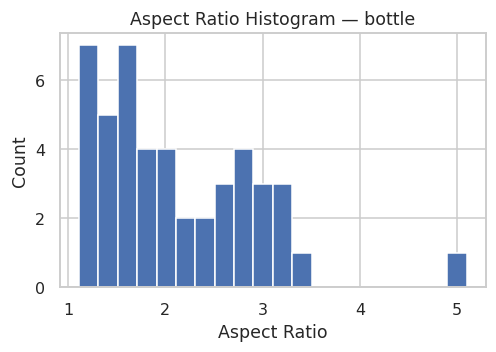

clip               P5=1.04  P95=3.09  N=11


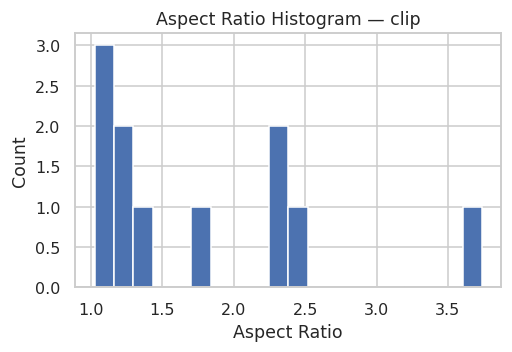

correction_tape    P5=1.60  P95=1.87  N=5


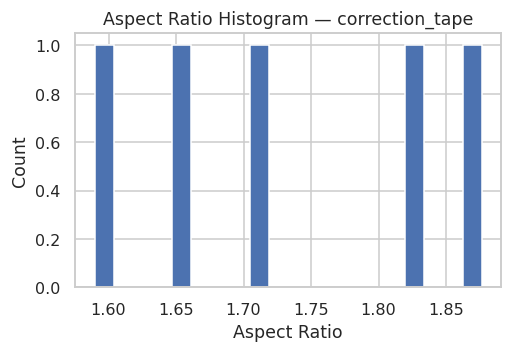

eraser             P5=1.05  P95=2.54  N=28


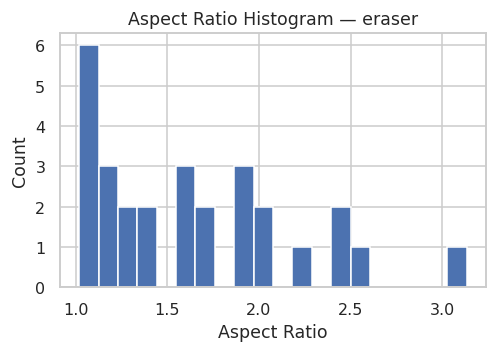

notebook           P5=1.01  P95=1.99  N=24


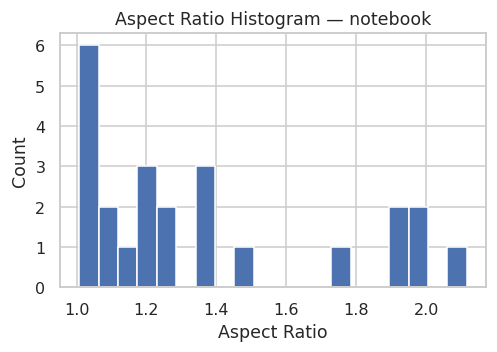

pen                P5=1.11  P95=14.97  N=24


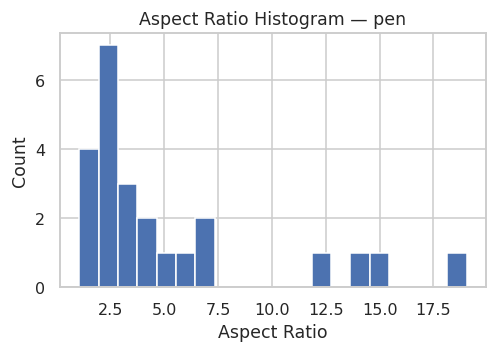

pencil             P5=1.30  P95=26.58  N=54


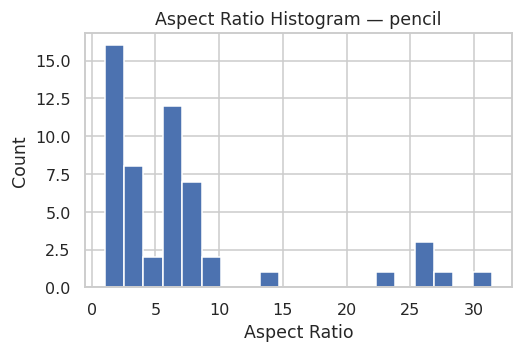

sharpener          P5=1.04  P95=2.43  N=28


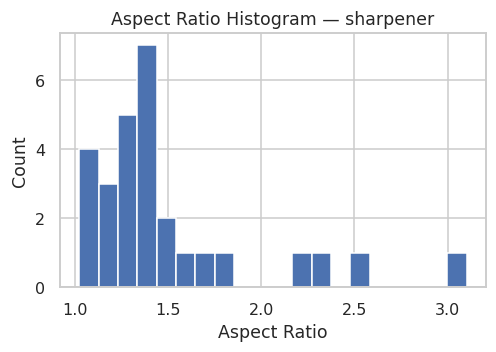

stapler            P5=1.05  P95=1.79  N=27


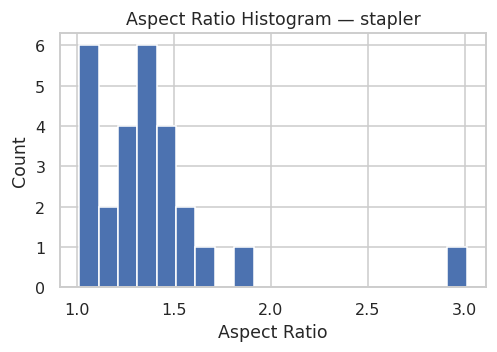

In [7]:
# D3 — Aspect Ratio Analysis dari Ground Truth

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

ar_by_class = defaultdict(list)

for rec in all_records:

    for det in rec['boxes']:

        cls = det['class']

        cx,cy,bw,bh = det['bbox_norm']

        if bw <= 0 or bh <= 0:
            continue

        ar = max(bw/bh, bh/bw)

        ar_by_class[cls].append(ar)

print("="*60)
print("Aspect Ratio Statistics (GT)")
print("="*60)

for cls, ars in sorted(ar_by_class.items()):

    if not ars:
        continue

    p5  = np.percentile(ars,5)
    p95 = np.percentile(ars,95)

    print(
        f"{cls:18s} "
        f"P5={p5:.2f}  "
        f"P95={p95:.2f}  "
        f"N={len(ars)}"
    )

    plt.figure(figsize=(5,3))
    plt.hist(ars,bins=20)
    plt.title(f"Aspect Ratio Histogram — {cls}")
    plt.xlabel("Aspect Ratio")
    plt.ylabel("Count")
    plt.show()

In [8]:
# Load Grounding DINO
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float32   # float32 + autocast lebih stabil dari manual float16

print(f'Device : {DEVICE}')
print(f'DType  : {DTYPE}')
print(f'Model  : {GDINO_MODEL_ID}')
print('Loading processor...')
processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)

print('Loading model weights...')
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GDINO_MODEL_ID, low_cpu_mem_usage=True,
).to(DEVICE).eval()

_pp_sig     = inspect.signature(processor.post_process_grounded_object_detection)
USE_NEW_API = 'box_threshold' not in _pp_sig.parameters
print(f'API post-process: {"new (threshold=)" if USE_NEW_API else "old (box_threshold=)"}')

def _gdino_raw(img_bgr, prompt, box_thr, text_thr):
    """Low-level inference. Identik dengan metode di app.py GroundingDINODetector.detect()."""
    img_pil   = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    inputs    = processor(images=img_pil, text=prompt, return_tensors='pt').to(DEVICE)
    input_ids = inputs['input_ids']   # simpan SEBELUM apapun
    with torch.inference_mode():
        with torch.autocast(device_type='cuda' if 'cuda' in DEVICE else 'cpu'):
            outputs = gdino_model(**inputs)
    kw = {'threshold': box_thr} if USE_NEW_API else \
         {'box_threshold': box_thr, 'text_threshold': text_thr}
    results = processor.post_process_grounded_object_detection(
        outputs, input_ids, target_sizes=[img_pil.size[::-1]], **kw,
    )
    preds=[]
    if results and results[0].get('boxes') is not None:
        for score,label,box in zip(
            results[0]['scores'],results[0]['labels'],results[0]['boxes']
        ):
            x1,y1,x2,y2=[int(v) for v in box.tolist()]
            preds.append({'label':str(label),'score':float(score),'bbox':[x1,y1,x2,y2]})
    return preds

_dummy = np.zeros((480,640,3),dtype=np.uint8)
_ = _gdino_raw(_dummy,'pen .',0.01,0.01)
print('Warmup OK.')
if torch.cuda.is_available():
    free,total=torch.cuda.mem_get_info(0)
    print(f'VRAM : {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
print('Model siap.')


Device : cuda
DType  : torch.float32
Model  : IDEA-Research/grounding-dino-base
Loading processor...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Loading model weights...


model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

API post-process: new (threshold=)
Warmup OK.
VRAM : 12.5 GB free / 15.6 GB total
Model siap.


In [9]:
# Fungsi evaluasi
def iou_box(a,b):
    ax1,ay1,ax2,ay2=a; bx1,by1,bx2,by2=b
    ix1=max(ax1,bx1); iy1=max(ay1,by1)
    ix2=min(ax2,bx2); iy2=min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if not inter: return 0.0
    union=(ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter
    return inter/union if union>0 else 0.0

def norm_to_pixel(cx,cy,bw,bh,W,H):
    x1=int((cx-bw/2)*W); y1=int((cy-bh/2)*H)
    x2=int((cx+bw/2)*W); y2=int((cy+bh/2)*H)
    return [max(0,x1),max(0,y1),min(W,x2),min(H,y2)]

def load_image_bgr(img_path):
    img=cv2.imread(str(img_path))
    if img is not None: return img
    try:
        pil=Image.open(str(img_path)).convert('RGB')
        return cv2.cvtColor(np.array(pil),cv2.COLOR_RGB2BGR)
    except: return None

def gdino_predict(img_bgr, prompt, box_thr=DEFAULT_BOX_THR, text_thr=DEFAULT_TEXT_THR):
    try:
        preds=_gdino_raw(img_bgr,prompt,box_thr,text_thr)
        return sorted(preds,key=lambda x:x['score'],reverse=True)
    except Exception as _e:
        print(f'gdino_predict error: {_e}'); return []

def evaluate_image(record, box_thr=DEFAULT_BOX_THR, text_thr=DEFAULT_TEXT_THR,
                   iou_thr=IOU_THRESHOLD):
    img=load_image_bgr(record['img_path'])
    if img is None: return {}
    H,W=img.shape[:2]
    gt_per_cls=defaultdict(list)
    for b in record['boxes']:
        gt_per_cls[b['class']].append(norm_to_pixel(*b['bbox_norm'],W,H))
    results={}
    for cls,gts in gt_per_cls.items():
        if cls not in CLASS_PROMPTS: continue
        prompt=CLASS_PROMPTS[cls]
        cls_box_thr=PER_CLASS_BOX_THR.get(cls,box_thr)
        preds=gdino_predict(img,prompt,cls_box_thr,text_thr)
        tp=fp=0; scores=[]; matched=set()
        for p in preds:
            scores.append(p['score'])
            best_iou=0.0; best_i=-1
            for i,gt in enumerate(gts):
                if i in matched: continue
                iou=iou_box(p['bbox'],gt)
                if iou>best_iou: best_iou=iou; best_i=i
            cls_iou=ADAPTIVE_IOU.get(cls,iou_thr)
            if best_iou>=cls_iou and best_i>=0: tp+=1; matched.add(best_i)
            else: fp+=1
        fn=len(gts)-tp
        results[cls]={'tp':tp,'fp':fp,'fn':fn,'n_gt':len(gts),'scores':scores}
    return results

def compute_metrics(agg):
    out={}
    for cls,r in agg.items():
        tp,fp,fn=r['tp'],r['fp'],r['fn']
        p=tp/(tp+fp) if tp+fp else 0.0
        rc=tp/(tp+fn) if tp+fn else 0.0
        f1=2*p*rc/(p+rc) if p+rc else 0.0
        out[cls]={'precision':round(p,4),'recall':round(rc,4),'f1':round(f1,4),
                  'tp':tp,'fp':fp,'fn':fn,'n_gt':r.get('n_gt',tp+fn)}
    return out

def stratified_sample(records,max_per_class=15):
    cls_to=defaultdict(list)
    for r in records:
        for b in r['boxes']: cls_to[b['class']].append(r)
    selected=set()
    for recs in cls_to.values():
        uniq=list({r['img_path']:r for r in recs}.values())
        random.shuffle(uniq)
        for r in uniq[:max_per_class]: selected.add(r['img_path'])
    return [r for r in records if r['img_path'] in selected]

print('Fungsi evaluasi siap.')
print(f'  gdino_predict : box_thr={DEFAULT_BOX_THR}, text_thr={DEFAULT_TEXT_THR}')
print(f'  iou matching  : default={IOU_THRESHOLD}, adaptive per kelas')
print(f'  per-class box : {PER_CLASS_BOX_THR}')


Fungsi evaluasi siap.
  gdino_predict : box_thr=0.35, text_thr=0.25
  iou matching  : default=0.5, adaptive per kelas
  per-class box : {'pencil': 0.22, 'clip': 0.22, 'correction_tape': 0.25, 'sharpener': 0.25, 'stapler': 0.25}


In [10]:
# Evaluasi utama
eval_records = all_records
print(f'Gambar untuk evaluasi : {len(eval_records)}')
print(f'Kelas yang dievaluasi : {EVAL_CLS_FINAL}')

agg    = defaultdict(lambda:{'tp':0,'fp':0,'fn':0,'n_gt':0,'scores':[]})
errors = []
t0     = time.time()

for rec in tqdm(eval_records, desc='DINO eval', ncols=80):
    try:
        res=evaluate_image(rec)
        for cls,r in res.items():
            agg[cls]['tp']+=r['tp']; agg[cls]['fp']+=r['fp']
            agg[cls]['fn']+=r['fn']; agg[cls]['n_gt']+=r['n_gt']
            agg[cls]['scores'].extend(r['scores'])
    except Exception as e: errors.append(str(e))

elapsed=time.time()-t0
print(f'\nSelesai  : {elapsed/60:.1f} menit')
print(f'Per gambar: {elapsed/max(1,len(eval_records)):.2f} detik')
if errors: print(f'Errors: {len(errors)}, contoh: {errors[:2]}')

metrics=compute_metrics({c:r for c,r in agg.items() if c in EVAL_CLS_FINAL})
rows=[]
for cls in sorted(metrics,key=lambda x:-metrics[x]['recall']):
    m=metrics[cls]
    rows.append({'Kelas':cls,'GT':m['n_gt'],'TP':m['tp'],'FP':m['fp'],
                 'FN':m['fn'],'Precision':m['precision'],'Recall':m['recall'],'F1':m['f1']})

df=pd.DataFrame(rows)
macro_p =df['Precision'].mean() if len(df) else 0.0
macro_r =df['Recall'].mean() if len(df) else 0.0
macro_f1=df['F1'].mean() if len(df) else 0.0

print(f'\nEvaluasi DINO (box={DEFAULT_BOX_THR} | text={DEFAULT_TEXT_THR} | iou={IOU_THRESHOLD}):')
print(df.to_string(index=False))
print()
print(f'  Macro Precision : {macro_p:.4f}')
print(f'  Macro Recall    : {macro_r:.4f}')
print(f'  Macro F1        : {macro_f1:.4f}')
df.to_csv(OUT_DIR/'dino_eval_main.csv',index=False)
print(f'\nDisimpan: {OUT_DIR}/dino_eval_main.csv')


Gambar untuk evaluasi : 148
Kelas yang dievaluasi : ['pen', 'eraser', 'notebook', 'pencil', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle']


DINO eval: 100%|██████████████████████████████| 148/148 [00:55<00:00,  2.67it/s]


Selesai  : 0.9 menit
Per gambar: 0.38 detik

Evaluasi DINO (box=0.35 | text=0.25 | iou=0.5):
          Kelas  GT  TP  FP  FN  Precision  Recall     F1
correction_tape   5   5   8   0     0.3846  1.0000 0.5556
         pencil  54  50 136   4     0.2688  0.9259 0.4167
       notebook  24  22  26   2     0.4583  0.9167 0.6111
           clip  11  10  17   1     0.3704  0.9091 0.5263
        stapler  27  24  49   3     0.3288  0.8889 0.4800
         eraser  28  19  27   9     0.4130  0.6786 0.5135
            pen  24  14   6  10     0.7000  0.5833 0.6364
      sharpener  28  16   8  12     0.6667  0.5714 0.6154
         bottle  46  24   9  22     0.7273  0.5217 0.6076

  Macro Precision : 0.4798
  Macro Recall    : 0.7773
  Macro F1        : 0.5514

Disimpan: /content/eval_results_dino/dino_eval_main.csv


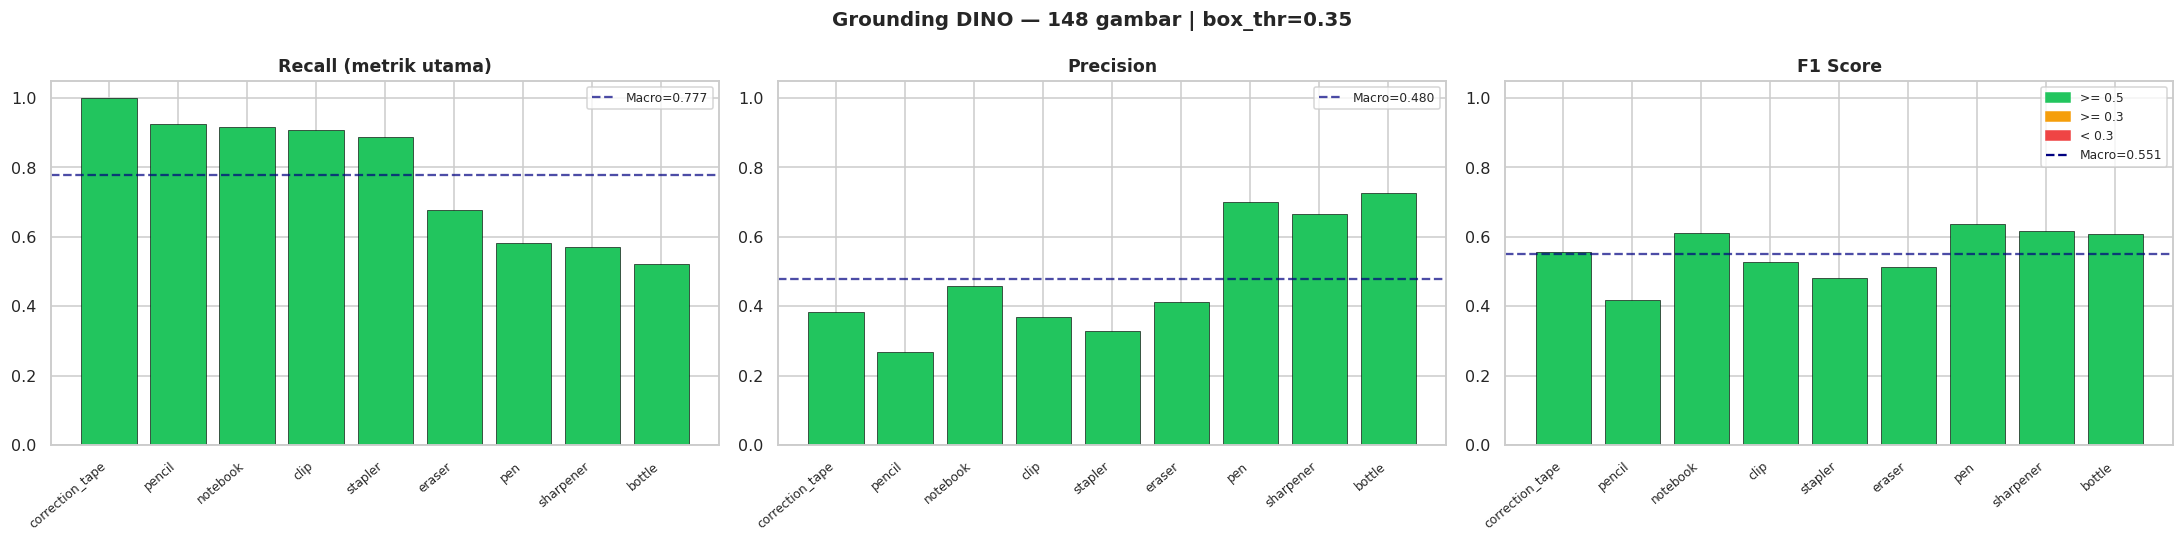

Disimpan: dino_eval_per_class.png


In [11]:
# Visualisasi per kelas
classes_sorted=df.sort_values('Recall',ascending=False)['Kelas'].tolist()
recalls=[metrics[c]['recall'] for c in classes_sorted]
precs  =[metrics[c]['precision'] for c in classes_sorted]
f1s    =[metrics[c]['f1'] for c in classes_sorted]
colors =['#22c55e' if v>=0.5 else ('#f59e0b' if v>=0.3 else '#ef4444') for v in recalls]

x=range(len(classes_sorted))
fig,axes=plt.subplots(1,3,figsize=(20,5))
for ax,vals,label,macro in [
    (axes[0],recalls,'Recall (metrik utama)',macro_r),
    (axes[1],precs,  'Precision',macro_p),
    (axes[2],f1s,    'F1 Score',macro_f1),
]:
    ax.bar(x,vals,color=colors,edgecolor='black',linewidth=0.4)
    ax.axhline(macro,color='navy',ls='--',alpha=0.7,label=f'Macro={macro:.3f}')
    ax.set_title(label,fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(classes_sorted,rotation=40,ha='right',fontsize=8)
    ax.set_ylim(0,1.05); ax.legend(fontsize=8)
axes[2].legend(handles=[
    mpatches.Patch(color='#22c55e',label='>= 0.5'),
    mpatches.Patch(color='#f59e0b',label='>= 0.3'),
    mpatches.Patch(color='#ef4444',label='< 0.3'),
    plt.Line2D([0],[0],color='navy',ls='--',label=f'Macro={macro_f1:.3f}'),
],fontsize=8)
plt.suptitle(f'Grounding DINO — {len(eval_records)} gambar | box_thr={DEFAULT_BOX_THR}',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'dino_eval_per_class.png'),dpi=130,bbox_inches='tight')
plt.show()
print('Disimpan: dino_eval_per_class.png')


Grid search: 105 gambar
Kombinasi  : 6 x 3 = 18 kombinasi


box_thr: 100%|██████████| 6/6 [13:29<00:00, 134.89s/it]



Hasil grid search (sorted by Macro F1):
 box_thr  text_thr  macro_f1  macro_r  macro_p
    0.35      0.20    0.5337   0.7604   0.4635
    0.35      0.10    0.5337   0.7604   0.4635
    0.35      0.25    0.5337   0.7604   0.4635
    0.30      0.20    0.5304   0.8802   0.3979
    0.30      0.10    0.5304   0.8802   0.3979
    0.30      0.25    0.5304   0.8802   0.3979
    0.40      0.25    0.4856   0.6786   0.4868
    0.40      0.10    0.4856   0.6786   0.4868
    0.40      0.20    0.4856   0.6786   0.4868
    0.20      0.10    0.4239   0.9017   0.3020
    0.20      0.25    0.4239   0.9017   0.3020
    0.20      0.20    0.4239   0.9017   0.3020
    0.50      0.20    0.3517   0.5225   0.3646
    0.50      0.10    0.3517   0.5225   0.3646
    0.50      0.25    0.3517   0.5225   0.3646
    0.10      0.10    0.3386   0.9113   0.2461
    0.10      0.20    0.3386   0.9113   0.2461
    0.10      0.25    0.3386   0.9113   0.2461

Best: box_thr=0.35  text_thr=0.2  F1=0.5337


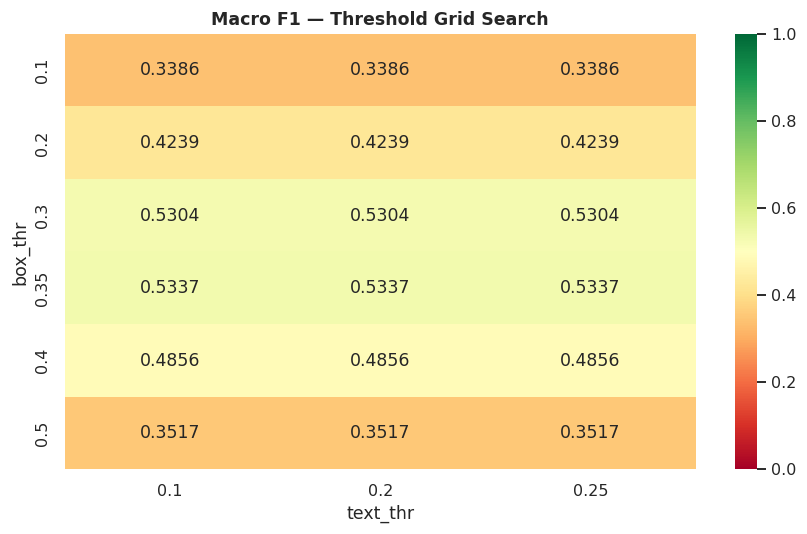

Disimpan: dino_eval_grid_search.png, dino_eval_grid_search.csv


In [12]:
# Grid search threshold
gs_records=stratified_sample(eval_records,max_per_class=15)
print(f'Grid search: {len(gs_records)} gambar')
print(f'Kombinasi  : {len(BOX_THRESHOLDS)} x {len(TEXT_THRESHOLDS)} = {len(BOX_THRESHOLDS)*len(TEXT_THRESHOLDS)} kombinasi')

grid_results=[]
for bt in tqdm(BOX_THRESHOLDS,desc='box_thr'):
    for tt in TEXT_THRESHOLDS:
        agg_gs=defaultdict(lambda:{'tp':0,'fp':0,'fn':0,'n_gt':0})
        for rec in gs_records:
            try:
                res=evaluate_image(rec,bt,tt,IOU_THRESHOLD)
                for cls,r in res.items():
                    for k in ('tp','fp','fn','n_gt'): agg_gs[cls][k]+=r[k]
            except: pass
        met=compute_metrics({c:r for c,r in agg_gs.items() if c in EVAL_CLS_FINAL})
        vals=list(met.values())
        grid_results.append({
            'box_thr':bt,'text_thr':tt,
            'macro_f1':round(np.mean([v['f1'] for v in vals]),4) if vals else 0,
            'macro_r' :round(np.mean([v['recall'] for v in vals]),4) if vals else 0,
            'macro_p' :round(np.mean([v['precision'] for v in vals]),4) if vals else 0,
        })

df_grid=pd.DataFrame(grid_results).sort_values('macro_f1',ascending=False)
print('\nHasil grid search (sorted by Macro F1):')
print(df_grid.to_string(index=False))
best=df_grid.iloc[0]
best_box=float(best.box_thr); best_txt=float(best.text_thr); best_f1=float(best.macro_f1)
print(f'\nBest: box_thr={best_box}  text_thr={best_txt}  F1={best_f1}')

pivot=df_grid.pivot(index='box_thr',columns='text_thr',values='macro_f1')
fig,ax=plt.subplots(figsize=(8,5))
sns.heatmap(pivot,annot=True,fmt='.4f',cmap='RdYlGn',ax=ax,vmin=0,vmax=1)
ax.set_title('Macro F1 — Threshold Grid Search',fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'dino_eval_grid_search.png'),dpi=130)
plt.show()
df_grid.to_csv(OUT_DIR/'dino_eval_grid_search.csv',index=False)
print('Disimpan: dino_eval_grid_search.png, dino_eval_grid_search.csv')


PR data: 100%|██████████████████████| 148/148 [00:57<00:00,  2.58it/s]


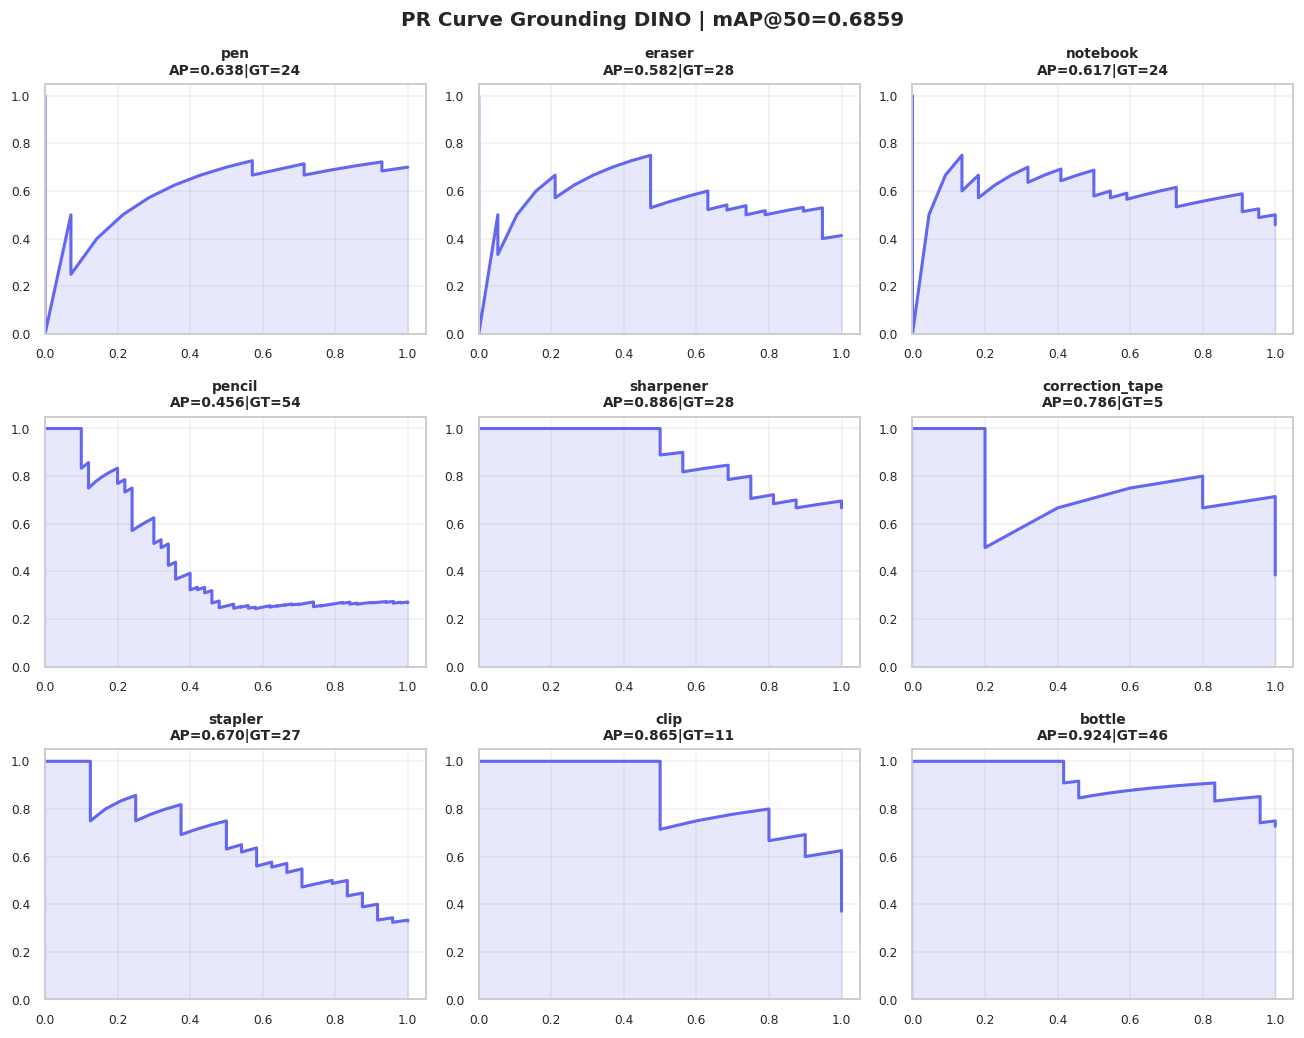

Disimpan: dino_eval_pr_curves.png

mAP Grounding DINO:
  mAP@30       : 0.7271  (longgar)
  mAP@50       : 0.6859  (PASCAL VOC standar)
  mAP@75       : 0.6338  (ketat)
  mAP@adaptive : 0.7139  (IoU per kelas)

  Kelas                   AP@adap   AP@30   AP@50   AP@75
  bottle                   0.9243  0.9243  0.9243  0.8406
  sharpener                0.8862  0.9236  0.8862  0.8550
  clip                     0.8645  0.8645  0.8383  0.8362
  correction_tape          0.7862  0.7862  0.7862  0.7862
  stapler                  0.6699  0.6493  0.6743  0.6546
  pen                      0.6382  0.6382  0.4981  0.4844
  notebook                 0.6172  0.6172  0.6172  0.6172
  eraser                   0.5820  0.6844  0.5820  0.4813
  pencil                   0.4564  0.4564  0.3665  0.1485


In [13]:
# PR Curves & mAP
cls_scores=defaultdict(list); cls_n_gt=defaultdict(int)

for rec in tqdm(eval_records,desc='PR data',ncols=70):
    try:
        img=load_image_bgr(rec['img_path'])
        if img is None: continue
        H,W=img.shape[:2]
        gt_per_cls=defaultdict(list)
        for b in rec['boxes']:
            gt_per_cls[b['class']].append(norm_to_pixel(*b['bbox_norm'],W,H))
            cls_n_gt[b['class']]+=1
        for cls in gt_per_cls:
            if cls not in CLASS_PROMPTS: continue
            prompt=CLASS_PROMPTS[cls]
            cls_box_thr=PER_CLASS_BOX_THR.get(cls,DEFAULT_BOX_THR)
            preds=sorted(gdino_predict(img,prompt,cls_box_thr,DEFAULT_TEXT_THR),
                         key=lambda x:x['score'],reverse=True)
            gts=gt_per_cls[cls]; matched=set()
            for p in preds:
                best_iou=0.0; best_i=-1
                for i,gt in enumerate(gts):
                    if i in matched: continue
                    iou=iou_box(p['bbox'],gt)
                    if iou>best_iou: best_iou=iou; best_i=i
                if best_i>=0 and best_iou>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD):
                    matched.add(best_i)
                cls_scores[cls].append((p['score'],best_iou))
    except: pass

cls_with_data=[c for c in EVAL_CLS_FINAL if cls_scores.get(c)]
ap_scores={}; ap_multi_iou={}

if cls_with_data:
    ncols=3; nrows=max(1,math.ceil(len(cls_with_data)/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*4,nrows*3.2))
    axes=np.array(axes).flatten() if hasattr(axes,'flatten') else np.array([axes])
    for i,cls in enumerate(cls_with_data):
        data=cls_scores[cls]; n_gt=cls_n_gt.get(cls,0)
        scores=np.array([d[0] for d in data]); ious=np.array([d[1] for d in data])
        labels=(ious>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD)).astype(int)
        aps_at={}
        for iou_t in [0.30,0.50,0.75]:
            lbl=(ious>=iou_t).astype(int)
            aps_at[iou_t]=float(average_precision_score(lbl,scores)) if lbl.sum()>0 else 0.0
        if labels.sum()==0:
            axes[i].set_title(f'{cls}\nAP=0.000|GT={n_gt}',fontsize=9,color='red')
            ap_scores[cls]=0.0; ap_multi_iou[cls]=aps_at
        else:
            try:
                pr,rc,_=precision_recall_curve(labels,scores)
                ap=float(average_precision_score(labels,scores))
                ap_scores[cls]=round(ap,4); ap_multi_iou[cls]=aps_at
                axes[i].plot(rc,pr,color='#6366f1',lw=2)
                axes[i].fill_between(rc,pr,alpha=0.15,color='#6366f1')
                axes[i].set_title(f'{cls}\nAP={ap:.3f}|GT={n_gt}',fontsize=9,fontweight='bold')
                axes[i].set_xlim(0,1.05); axes[i].set_ylim(0,1.05)
                axes[i].tick_params(labelsize=8); axes[i].grid(True,alpha=0.3)
            except: ap_scores[cls]=0.0
    for j in range(len(cls_with_data),len(axes)): axes[j].set_visible(False)
    mAP_50_val=sum(v.get(0.50,0) for v in ap_multi_iou.values())/max(1,len(ap_multi_iou))
    plt.suptitle(f'PR Curve Grounding DINO | mAP@50={mAP_50_val:.4f}',fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'dino_eval_pr_curves.png'),dpi=120,bbox_inches='tight')
    plt.show()
    print('Disimpan: dino_eval_pr_curves.png')

mAP =float(np.mean(list(ap_scores.values()))) if ap_scores else 0.0
mAP_30=float(np.mean([v.get(0.30,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_50=float(np.mean([v.get(0.50,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_75=float(np.mean([v.get(0.75,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0

print(f'\nmAP Grounding DINO:')
print(f'  mAP@30       : {mAP_30:.4f}  (longgar)')
print(f'  mAP@50       : {mAP_50:.4f}  (PASCAL VOC standar)')
print(f'  mAP@75       : {mAP_75:.4f}  (ketat)')
print(f'  mAP@adaptive : {mAP:.4f}  (IoU per kelas)')
print()
print(f'  {"Kelas":<22} {"AP@adap":>8} {"AP@30":>7} {"AP@50":>7} {"AP@75":>7}')
for cls,ap in sorted(ap_scores.items(),key=lambda x:-x[1]):
    aps=ap_multi_iou.get(cls,{})
    print(f'  {cls:<22} {ap:>8.4f} {aps.get(0.30,0):>7.4f} {aps.get(0.50,0):>7.4f} {aps.get(0.75,0):>7.4f}')
gc.collect(); torch.cuda.empty_cache()


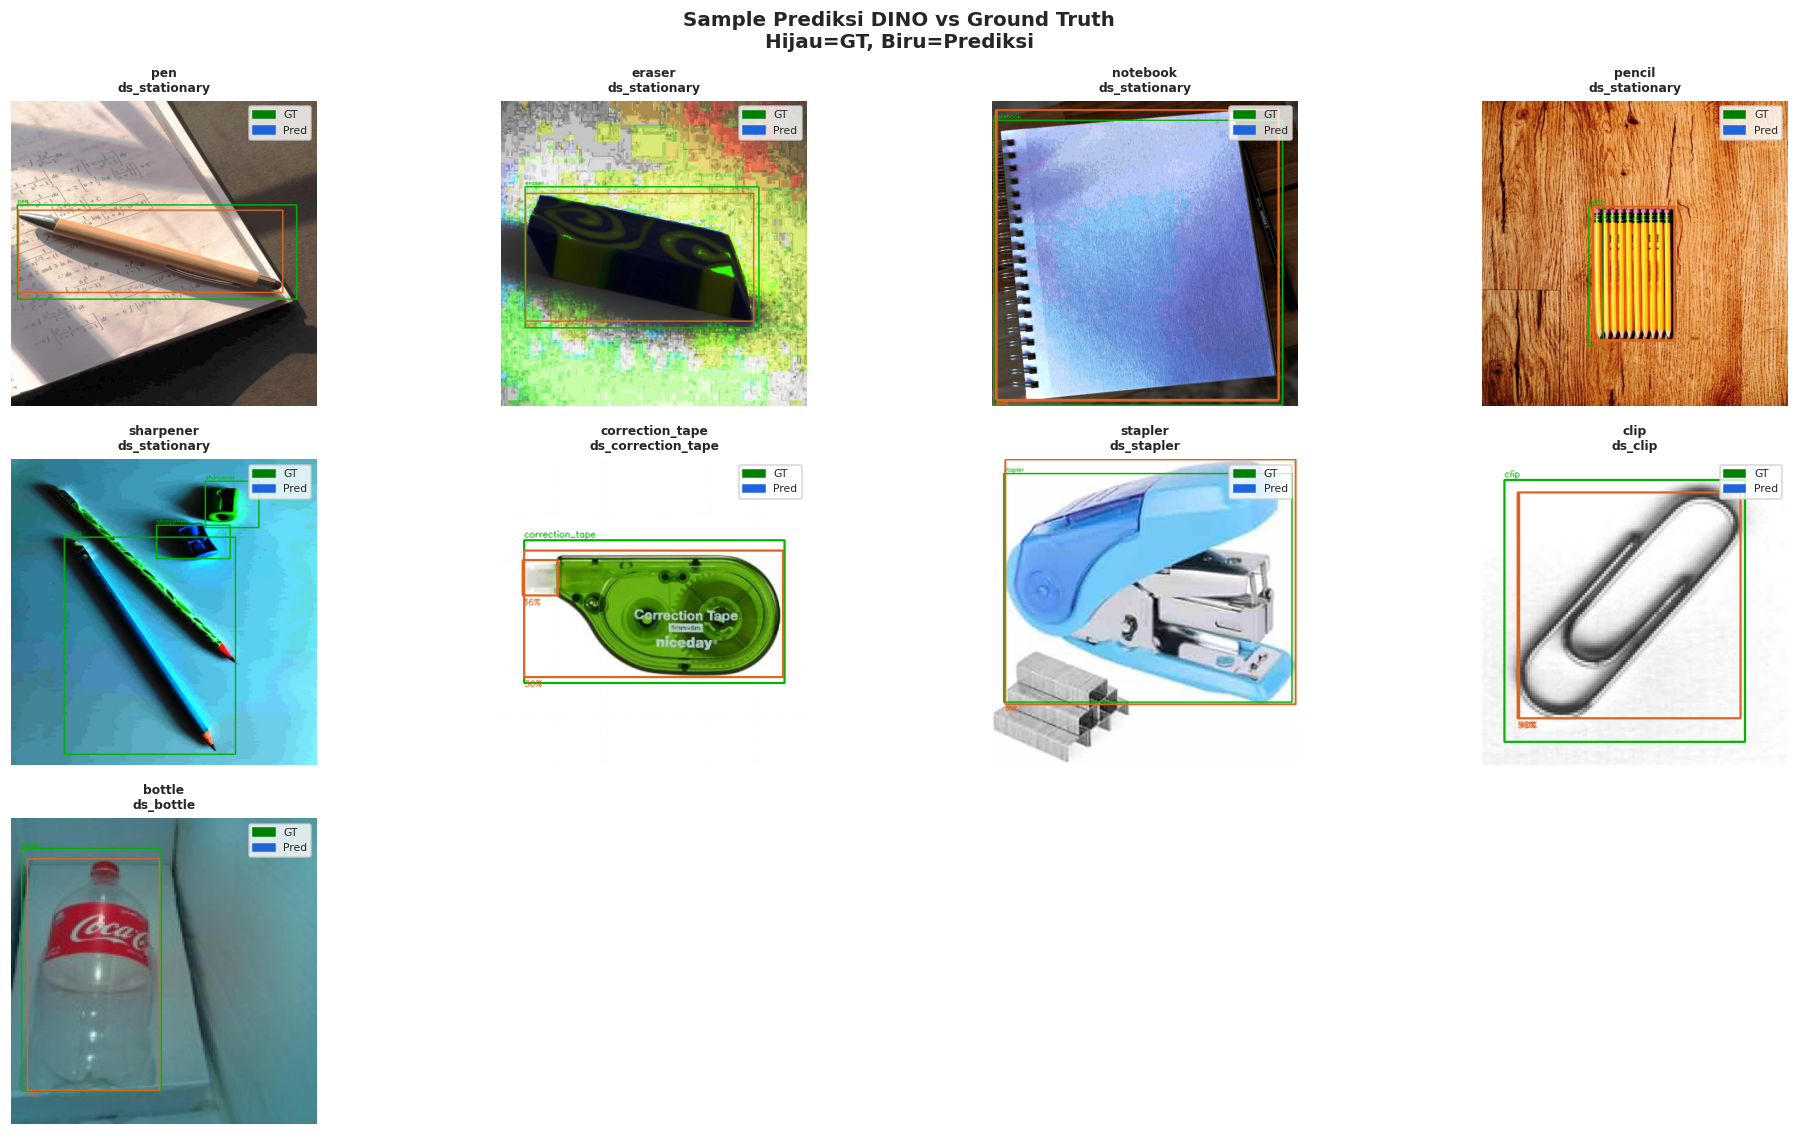

Disimpan: dino_eval_sample_viz.png


In [14]:
# Sample visualisasi
def draw_compare(img_bgr,gt_boxes,pred_boxes):
    vis=img_bgr.copy(); H,W=vis.shape[:2]
    for b in gt_boxes:
        px=norm_to_pixel(*b['bbox_norm'],W,H)
        cv2.rectangle(vis,(px[0],px[1]),(px[2],px[3]),(0,180,0),2)
        cv2.putText(vis,b['class'],(px[0],max(px[1]-4,10)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.4,(0,180,0),1,cv2.LINE_AA)
    for p in pred_boxes:
        x1,y1,x2,y2=p['bbox']
        cv2.rectangle(vis,(x1,y1),(x2,y2),(30,100,220),2)
        cv2.putText(vis,f'{p["score"]*100:.0f}%',(x1,min(y2+13,H-2)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.38,(30,100,220),1,cv2.LINE_AA)
    return cv2.cvtColor(vis,cv2.COLOR_BGR2RGB)

sample_recs=[]; seen_cls=set()
for cls in EVAL_CLS_FINAL:
    for r in eval_records:
        if any(b['class']==cls for b in r['boxes']) and cls not in seen_cls:
            sample_recs.append((cls,r)); seen_cls.add(cls); break
    if len(sample_recs)>=12: break

if sample_recs:
    ncols=4; nrows=max(1,math.ceil(len(sample_recs)/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*4.5,nrows*3.5))
    axes=np.array(axes).flatten() if hasattr(axes,'flatten') else np.array([axes])
    for i,(cls,rec) in enumerate(sample_recs):
        img=load_image_bgr(rec['img_path'])
        if img is None: axes[i].axis('off'); continue
        preds=gdino_predict(img,CLASS_PROMPTS.get(cls,cls+' .'))
        vis=draw_compare(img,rec['boxes'],preds)
        axes[i].imshow(vis); axes[i].axis('off')
        axes[i].set_title(f'{cls}\n{rec["ds_name"]}',fontsize=8,fontweight='bold')
        axes[i].legend(handles=[
            mpatches.Patch(color='green',label='GT'),
            mpatches.Patch(color='#1e64dc',label='Pred'),
        ],loc='upper right',fontsize=7)
    for j in range(len(sample_recs),len(axes)): axes[j].set_visible(False)
    plt.suptitle('Sample Prediksi DINO vs Ground Truth\nHijau=GT, Biru=Prediksi',
                 fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'dino_eval_sample_viz.png'),dpi=110,bbox_inches='tight')
    plt.show()
    print('Disimpan: dino_eval_sample_viz.png')


In [15]:
# Analisis error
df_err=df.copy()
df_err['FP_rate']=df_err['FP']/(df_err['TP']+df_err['FP']+1e-6)
df_err['FN_rate']=df_err['FN']/(df_err['GT']+1e-6)
print('-'*60)
print('Top 5 — False Positive terbanyak (over-detect):')
print(df_err.nlargest(5,'FP')[['Kelas','GT','TP','FP','FP_rate']].to_string(index=False))
print()
print('Top 5 — False Negative terbanyak (miss-detect):')
print(df_err.nlargest(5,'FN_rate')[['Kelas','GT','TP','FN','FN_rate']].to_string(index=False))
print()
print('-'*60)
print('Rekomendasi per kelas:')
for _,row in df.sort_values('Recall',ascending=False).iterrows():
    cls=row['Kelas']; rc=row['Recall']; p=row['Precision']
    if rc>=0.6 and p>=0.4:   act='Baik, pertahankan'
    elif rc>=0.6 and p<0.4:  act='Recall OK tapi Precision rendah → naikkan box_threshold per kelas'
    elif rc<0.3:              act='Recall rendah → perkaya prompt / turunkan threshold'
    else:                     act='Perlu tuning threshold'
    print(f'  {cls:<22} Recall={rc:.3f}  Prec={p:.3f}  → {act}')


------------------------------------------------------------
Top 5 — False Positive terbanyak (over-detect):
   Kelas  GT  TP  FP  FP_rate
  pencil  54  50 136 0.731183
 stapler  27  24  49 0.671233
  eraser  28  19  27 0.586957
notebook  24  22  26 0.541667
    clip  11  10  17 0.629630

Top 5 — False Negative terbanyak (miss-detect):
    Kelas  GT  TP  FN  FN_rate
   bottle  46  24  22 0.478261
sharpener  28  16  12 0.428571
      pen  24  14  10 0.416667
   eraser  28  19   9 0.321429
  stapler  27  24   3 0.111111

------------------------------------------------------------
Rekomendasi per kelas:
  correction_tape        Recall=1.000  Prec=0.385  → Recall OK tapi Precision rendah → naikkan box_threshold per kelas
  pencil                 Recall=0.926  Prec=0.269  → Recall OK tapi Precision rendah → naikkan box_threshold per kelas
  notebook               Recall=0.917  Prec=0.458  → Baik, pertahankan
  clip                   Recall=0.909  Prec=0.370  → Recall OK tapi Precision rend

In [16]:
# Export eval_summary_dino.json
try: _best_box=float(best_box); _best_txt=float(best_txt); _best_f1=float(best_f1)
except NameError: _best_box=DEFAULT_BOX_THR; _best_txt=DEFAULT_TEXT_THR; _best_f1=macro_f1

per_class_metrics={}
for cls in TARGET_9_CLASSES:
    if cls in metrics:
        m=metrics[cls]; ap=ap_scores.get(cls,0.0)
        aps=ap_multi_iou.get(cls,{})
        per_class_metrics[cls]={
            'precision'      : m['precision'],
            'recall'         : m['recall'],
            'f1_score'       : m['f1'],
            'ap'             : round(ap,4),
            'ap_50'          : round(aps.get(0.50,0),4),
            'ap_75'          : round(aps.get(0.75,0),4),
            'ap_30'          : round(aps.get(0.30,0),4),
            'true_positives' : m['tp'],
            'false_positives': m['fp'],
            'false_negatives': m['fn'],
            'n_gt'           : m['n_gt'],
            'has_gt'         : True,
        }
    else:
        per_class_metrics[cls]={
            'precision':0.0,'recall':0.0,'f1_score':0.0,
            'ap':0.0,'ap_50':0.0,'ap_75':0.0,'ap_30':0.0,
            'true_positives':0,'false_positives':0,'false_negatives':0,
            'n_gt':0,'has_gt':False,
        }

summary={
    'model_name'    : 'grounding_dino_base',
    'model_arch'    : GDINO_MODEL_ID,
    'target_classes': TARGET_9_CLASSES,
    'class_prompts' : CLASS_PROMPTS,
    'eval_config'   : {
        'box_threshold'      : DEFAULT_BOX_THR,
        'text_threshold'     : DEFAULT_TEXT_THR,
        'iou_threshold'      : IOU_THRESHOLD,
        'adaptive_iou'       : ADAPTIVE_IOU,
        'per_class_box_thr'  : PER_CLASS_BOX_THR,
        'n_eval_images'      : len(eval_records),
        'min_gt_per_class'   : MIN_GT,
    },
    'overall_map'       : round(mAP,4),
    'overall_map_50'    : round(mAP_50,4),
    'overall_map_75'    : round(mAP_75,4),
    'overall_map_30'    : round(mAP_30,4),
    'overall_precision' : round(macro_p,4),
    'overall_recall'    : round(macro_r,4),
    'overall_f1'        : round(macro_f1,4),
    'macro_metrics': {
        'precision'   : round(macro_p,4),
        'recall'      : round(macro_r,4),
        'f1'          : round(macro_f1,4),
        'mAP_30'      : round(mAP_30,4),
        'mAP_50'      : round(mAP_50,4),
        'mAP_75'      : round(mAP_75,4),
        'mAP_adaptive': round(mAP,4),
    },
    'grid_search': {
        'best_box_thr' : _best_box,
        'best_text_thr': _best_txt,
        'best_macro_f1': _best_f1,
    },
    'per_class_metrics': per_class_metrics,
}

out_path=OUT_DIR/'eval_summary_dino.json'
with open(out_path,'w') as f: json.dump(summary,f,indent=2)
print(f'eval_summary_dino.json disimpan ke: {out_path}')
print(f'  Size: {out_path.stat().st_size/1024:.1f} KB')
print()
print(f'  {"Kelas":<22} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AP@50":>8} {"GT":>5}')
for cls in TARGET_9_CLASSES:
    m=per_class_metrics[cls]
    if m['has_gt']:
        print(f'  {cls:<22} {m["precision"]:>10.4f} {m["recall"]:>8.4f} '
              f'{m["f1_score"]:>8.4f} {m["ap_50"]:>8.4f} {m["n_gt"]:>5}')
    else:
        print(f'  {cls:<22} (tidak ada GT)')
print()
print(f'  Overall mAP@50 : {summary["overall_map_50"]:.4f}')
print(f'  Overall Recall : {summary["overall_recall"]:.4f}')


eval_summary_dino.json disimpan ke: /content/eval_results_dino/eval_summary_dino.json
  Size: 5.2 KB

  Kelas                   Precision   Recall       F1    AP@50    GT
  pen                        0.7000   0.5833   0.6364   0.4981    24
  pencil                     0.2688   0.9259   0.4167   0.3665    54
  eraser                     0.4130   0.6786   0.5135   0.5820    28
  sharpener                  0.6667   0.5714   0.6154   0.8862    28
  correction_tape            0.3846   1.0000   0.5556   0.7862     5
  stapler                    0.3288   0.8889   0.4800   0.6743    27
  clip                       0.3704   0.9091   0.5263   0.8383    11
  bottle                     0.7273   0.5217   0.6076   0.9243    46
  notebook                   0.4583   0.9167   0.6111   0.6172    24

  Overall mAP@50 : 0.6859
  Overall Recall : 0.7773


In [17]:
# Download
print('File yang dihasilkan di', OUT_DIR)
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name:<45} ({p.stat().st_size/1024:.1f} KB)')

from google.colab import files as colab_files
print('\nDownload eval_summary_dino.json (FILE UTAMA untuk WBF Ensemble)...')
try:
    colab_files.download(str(OUT_DIR/'eval_summary_dino.json'))
    print('  OK')
except Exception as e:
    print(f'  Error: {e}')

print('\nDownload file pendukung (opsional):')
for fname in ['dino_eval_main.csv','dino_eval_per_class.png',
              'dino_eval_pr_curves.png','dino_eval_sample_viz.png',
              'dino_eval_grid_search.png','dino_eval_grid_search.csv']:
    fp=OUT_DIR/fname
    if fp.exists():
        try: colab_files.download(str(fp)); print(f'  OK: {fname}')
        except: pass

print('\nSelesai. eval_summary_dino.json siap digunakan di WBF Ensemble Notebook.')


File yang dihasilkan di /content/eval_results_dino
  dino_eval_grid_search.csv                     (0.6 KB)
  dino_eval_grid_search.png                     (38.4 KB)
  dino_eval_main.csv                            (0.4 KB)
  dino_eval_per_class.png                       (68.7 KB)
  dino_eval_pr_curves.png                       (101.7 KB)
  dino_eval_sample_viz.png                      (1150.6 KB)
  eval_summary_dino.json                        (5.2 KB)

Download eval_summary_dino.json (FILE UTAMA untuk WBF Ensemble)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK

Download file pendukung (opsional):


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  OK: dino_eval_grid_search.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: dino_eval_grid_search.csv

Selesai. eval_summary_dino.json siap digunakan di WBF Ensemble Notebook.
